*ENGLISH PROFICIENCY PART*

In [2]:
#1. CREATE AN ENGLISH SKILLS CLASSIFIER

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1) Simulate sample data with realistic proficiency distribution
np.random.seed(42)
n = 400

# Generate data with three distinct proficiency groups
# Low: ~33%, Medium: ~40%, High: ~27%
n_low = 132
n_mid = 160
n_high = 108

# Low proficiency (scores 0.0-0.5)
low_data = {
    "vocab_norm": np.random.uniform(0.0, 0.5, n_low),
    "grammar_norm": np.random.uniform(0.0, 0.5, n_low),
    "reading_norm": np.random.uniform(0.0, 0.5, n_low),
    "writing_norm": np.random.uniform(0.0, 0.5, n_low)
}

# Medium proficiency (scores 0.4-0.75)
mid_data = {
    "vocab_norm": np.random.uniform(0.4, 0.75, n_mid),
    "grammar_norm": np.random.uniform(0.4, 0.75, n_mid),
    "reading_norm": np.random.uniform(0.4, 0.75, n_mid),
    "writing_norm": np.random.uniform(0.4, 0.75, n_mid)
}

# High proficiency (scores 0.65-1.0)
high_data = {
    "vocab_norm": np.random.uniform(0.65, 1.0, n_high),
    "grammar_norm": np.random.uniform(0.65, 1.0, n_high),
    "reading_norm": np.random.uniform(0.65, 1.0, n_high),
    "writing_norm": np.random.uniform(0.65, 1.0, n_high)
}

# Combine all groups
df = pd.DataFrame({
    "vocab_norm": np.concatenate([low_data["vocab_norm"], mid_data["vocab_norm"], high_data["vocab_norm"]]),
    "grammar_norm": np.concatenate([low_data["grammar_norm"], mid_data["grammar_norm"], high_data["grammar_norm"]]),
    "reading_norm": np.concatenate([low_data["reading_norm"], mid_data["reading_norm"], high_data["reading_norm"]]),
    "writing_norm": np.concatenate([low_data["writing_norm"], mid_data["writing_norm"], high_data["writing_norm"]])
})

# Shuffle the dataframe
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

skill_cols = [
    "vocab_norm","grammar_norm","reading_norm",
    "writing_norm"
]

# 3) Create label based on average skill level
df["avg_skill"] = df[skill_cols].mean(axis=1)

def to_label(x):
    if x >= 0.75: return 2   # High
    elif x >= 0.50: return 1 # Medium
    else: return 0           # Low

df["proficiency_label"] = df["avg_skill"].apply(to_label)

# Print class distribution
print("Class Distribution:")
print(df["proficiency_label"].value_counts().sort_index())
print(f"\nLow: {(df['proficiency_label']==0).sum()}, Medium: {(df['proficiency_label']==1).sum()}, High: {(df['proficiency_label']==2).sum()}")

# 4) Train classifier
X = df[skill_cols]
y = df["proficiency_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=3, target_names=["Low", "Medium", "High"]))

# 5) Save model for Streamlit
import joblib
joblib.dump(clf, "english_proficiency_model.pkl")
print("\nModel saved as 'english_proficiency_model.pkl'")


Class Distribution:
proficiency_label
0    142
1    156
2    102
Name: count, dtype: int64

Low: 142, Medium: 156, High: 102

Classification Report:
              precision    recall  f1-score   support

         Low      1.000     0.944     0.971        36
      Medium      0.951     1.000     0.975        39
        High      1.000     1.000     1.000        25

    accuracy                          0.980       100
   macro avg      0.984     0.981     0.982       100
weighted avg      0.981     0.980     0.980       100


Classification Report:
              precision    recall  f1-score   support

         Low      1.000     0.944     0.971        36
      Medium      0.951     1.000     0.975        39
        High      1.000     1.000     1.000        25

    accuracy                          0.980       100
   macro avg      0.984     0.981     0.982       100
weighted avg      0.981     0.980     0.980       100


Model saved as 'english_proficiency_model.pkl'

Model saved as '

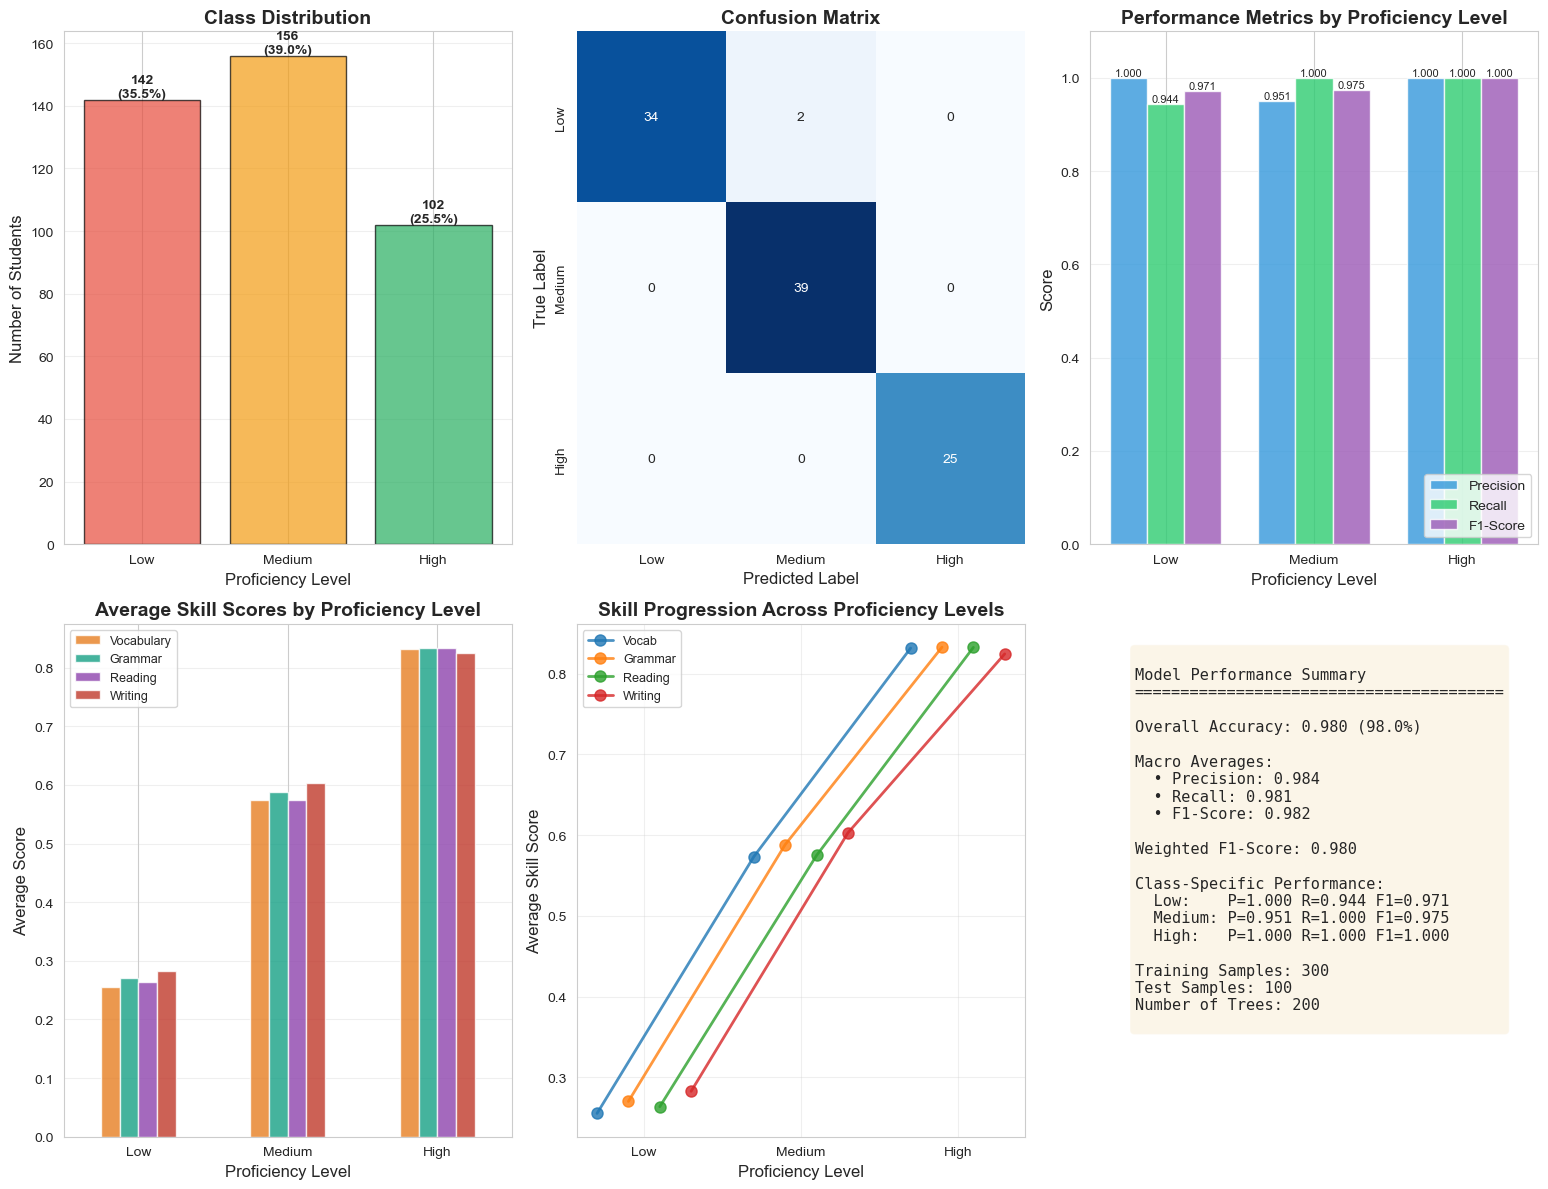


Visualization saved as 'english_proficiency_model_performance.png'


In [ ]:
#2. VISUALIZATIONS

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# Create a figure with multiple subplots
fig = plt.figure(figsize=(16, 12))

# 1. Class Distribution
ax1 = plt.subplot(2, 3, 1)
class_counts = df["proficiency_label"].value_counts().sort_index()
colors = ['#e74c3c', '#f39c12', '#27ae60']
bars = ax1.bar(['Low', 'Medium', 'High'], class_counts.values, color=colors, alpha=0.7, edgecolor='black')
ax1.set_title('Class Distribution', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Students', fontsize=12)
ax1.set_xlabel('Proficiency Level', fontsize=12)
for bar, count in zip(bars, class_counts.values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({count/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# 2. Confusion Matrix
ax2 = plt.subplot(2, 3, 2)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'], ax=ax2)
ax2.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax2.set_ylabel('True Label', fontsize=12)
ax2.set_xlabel('Predicted Label', fontsize=12)

# 3. Performance Metrics by Class
ax3 = plt.subplot(2, 3, 3)
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred)
x = np.arange(3)
width = 0.25
bars1 = ax3.bar(x - width, precision, width, label='Precision', color='#3498db', alpha=0.8)
bars2 = ax3.bar(x, recall, width, label='Recall', color='#2ecc71', alpha=0.8)
bars3 = ax3.bar(x + width, f1, width, label='F1-Score', color='#9b59b6', alpha=0.8)
ax3.set_title('Performance Metrics by Proficiency Level', fontsize=14, fontweight='bold')
ax3.set_ylabel('Score', fontsize=12)
ax3.set_xlabel('Proficiency Level', fontsize=12)
ax3.set_xticks(x)
ax3.set_xticklabels(['Low', 'Medium', 'High'])
ax3.legend(loc='lower right', fontsize=10)
ax3.set_ylim([0, 1.1])
ax3.grid(axis='y', alpha=0.3)
# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=8)

# 4. Average Skill Scores by Proficiency Level
ax4 = plt.subplot(2, 3, 4)
skill_means = df.groupby('proficiency_label')[skill_cols].mean()
skill_means.index = ['Low', 'Medium', 'High']
skill_means.plot(kind='bar', ax=ax4, color=['#e67e22', '#16a085', '#8e44ad', '#c0392b'], alpha=0.8)
ax4.set_title('Average Skill Scores by Proficiency Level', fontsize=14, fontweight='bold')
ax4.set_ylabel('Average Score', fontsize=12)
ax4.set_xlabel('Proficiency Level', fontsize=12)
ax4.legend(['Vocabulary', 'Grammar', 'Reading', 'Writing'], loc='upper left', fontsize=9)
ax4.set_xticklabels(['Low', 'Medium', 'High'], rotation=0)
ax4.grid(axis='y', alpha=0.3)

# 5. Skill Distribution Across Proficiency Levels
ax5 = plt.subplot(2, 3, 5)
proficiency_labels_text = df['proficiency_label'].map({0: 'Low', 1: 'Medium', 2: 'High'})
for i, skill in enumerate(skill_cols):
    positions = np.arange(3) + i * 0.2
    means = [df[df['proficiency_label']==level][skill].mean() for level in [0, 1, 2]]
    ax5.plot(positions, means, marker='o', linewidth=2, markersize=8, 
            label=skill.replace('_norm', '').capitalize(), alpha=0.8)
ax5.set_title('Skill Progression Across Proficiency Levels', fontsize=14, fontweight='bold')
ax5.set_ylabel('Average Skill Score', fontsize=12)
ax5.set_xlabel('Proficiency Level', fontsize=12)
ax5.set_xticks(np.arange(3) + 0.3)
ax5.set_xticklabels(['Low', 'Medium', 'High'])
ax5.legend(loc='upper left', fontsize=9)
ax5.grid(alpha=0.3)

# 6. Model Performance Summary
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
overall_accuracy = (y_pred == y_test).sum() / len(y_test)
macro_precision = precision.mean()
macro_recall = recall.mean()
macro_f1 = f1.mean()
weighted_f1 = f1.dot(support) / support.sum()

summary_text = f"""
Model Performance Summary
{'='*40}

Overall Accuracy: {overall_accuracy:.3f} ({overall_accuracy*100:.1f}%)

Macro Averages:
  • Precision: {macro_precision:.3f}
  • Recall: {macro_recall:.3f}
  • F1-Score: {macro_f1:.3f}

Weighted F1-Score: {weighted_f1:.3f}

Class-Specific Performance:
  Low:    P={precision[0]:.3f} R={recall[0]:.3f} F1={f1[0]:.3f}
  Medium: P={precision[1]:.3f} R={recall[1]:.3f} F1={f1[1]:.3f}
  High:   P={precision[2]:.3f} R={recall[2]:.3f} F1={f1[2]:.3f}

Training Samples: {len(X_train)}
Test Samples: {len(X_test)}
Number of Trees: 200
"""
ax6.text(0.1, 0.95, summary_text, transform=ax6.transAxes,
        fontsize=11, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig('english_proficiency_model_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("Visualization saved as 'english_proficiency_model_performance.png'")
print("="*60)

In [ ]:
#3 RECOMMENDATION RULES

LOW, MID = 0.60, 0.80
FEEDBACK = {
    "Vocabulary": {"Needs Work": "Do 20 vocab cards/day + 5 collocations.",
                   "Adequate": "Keep 10 cards/day, mix B1–B2 sets.",
                   "Strong": "Advance to B2–C1 vocabulary and review weekly."},
    "Grammar": {"Needs Work": "15 tense/cloze per day + S–V agreement.",
                "Adequate": "8 mixed grammar exercises/day.",
                "Strong": "Complex clauses 2×/week."},
    "Sentence Structure": {"Needs Work": "2 ordering exercises/day.",
                           "Adequate": "1 ordering + clause combining.",
                           "Strong": "Paragraph cohesion tasks."},

    "Reading": {"Needs Work": "Cloze + inference on graded texts.",
                "Adequate": "Alternate cloze/inference exercises.",
                "Strong": "Longer texts + summaries."},
    "Writing": {"Needs Work": "Fix 5 sentences/day.",
                "Adequate": "Write one paragraph/day.",
                "Strong": "Weekly essay or reflection."},
}
def level_from_score(s):
    if s < LOW: return "Needs Work"
    if s < MID: return "Adequate"
    return "Strong"

def build_recommendations(scores: dict, top_k: int = 3):
    """
    scores = {'Vocabulary':0.7, 'Grammar':0.4, ...}
    returns top-k weakest skills and their recommendations
    """
    items = []
    for skill, s in scores.items():
        lvl = level_from_score(s)
        if s < LOW: gap = LOW - s
        elif s < MID: gap = MID - s
        else: gap = 1.0 - s
        items.append({
            "skill": skill,
            "score": round(s, 2),
            "level": lvl,
            "gap": round(gap, 2),
            "recommendation": FEEDBACK.get(skill, {}).get(lvl, "Practice regularly.")
        })
    items = sorted(items, key=lambda x: x["gap"], reverse=True)
    return items[:top_k], items
